## DFG: Delta Functional Group Analysis
**Version:** 1.0.2  
**Release date:** 2026-04-26  
**Changes in this version:** changed the last figure to have fractions on the outside for easier viewing

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [77]:
#Import you data. Note that the data should be three columns: mass, formula, frac_abundance. The abundance needs to be normalized to sum = 1.
from IPython.display import display
data_path = '/content/drive/My Drive/Research/' #this should be your data path in google drive
df = pd.read_csv(data_path+'DUARE_COA.csv')    #this should be the name of your data file
display(df.head())

,mass,formula,frac_abundance
0,12.00000,C,8.360862e-03
1,13.00782,CH,3.532820e-03
2,14.01565,CH2,3.640000e-11
3,15.02347,CH3,2.701451e-02
4,15.99492,O,2.994240e-04


In [78]:
#Parse the chemical formulas. This will create a list of the number of carbon, hydrogen, oxygen, etc. atoms from the formula column.
import re

def parse_formula(formula):
    """
    Parses a chemical formula string to extract the counts of C, H, O, N, S, F, Cl, Br, I, Cu,
    and a flag for 'j' (isotopes).

    Args:
        formula: A string representing the chemical formula.

    Returns:
        A dictionary with keys 'C', 'H', 'O', 'N', 'S', 'F', 'Cl', 'Br', 'I', 'Cu', 'j' and their respective counts/flags.
        Returns all zeros for counts/flags if the input is not a valid string.
    """
    counts = {'C': 0, 'H': 0, 'O': 0, 'N': 0, 'S': 0, 'F': 0, 'Cl': 0, 'Br': 0, 'I': 0, 'Cu': 0, 'j': 0}
    if not isinstance(formula, str):
        return counts

    # Check for 'j' for isotopes (case-insensitive)
    if 'j' in formula.lower():
        counts['j'] = 1

    # Find all element symbols and their counts using regex
    # Matches elements like 'C', 'H', 'O', 'N', 'S', 'F', 'Cl', 'Br', 'I', 'Cu'
    # '([A-Z][a-z]?)' will match 'C', 'Cl', 'Cu' etc.
    matches = re.findall(r'([A-Z][a-z]?)(\d*)', formula)

    for element, count_str in matches:
        count = int(count_str) if count_str else 1
        if element in counts:
            counts[element] += count

    return counts

In [79]:
#Create a table of the data with formulas and calculate the delta values
formula_counts = df['formula'].apply(parse_formula)
formula_counts_df = pd.DataFrame(list(formula_counts))

# Identify columns that might be duplicated (element counts and 'j')
potential_duplicate_cols = ['C', 'H', 'O', 'N', 'S', 'F', 'Cl', 'Br', 'I', 'Cu', 'j']
# Filter for columns that actually exist in df before dropping
cols_to_drop = [col for col in potential_duplicate_cols if col in df.columns]

# Drop these columns from df if they already exist to prevent duplicates in case of re-running cells
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

#Concatenate the original df with the new element count columns
df = pd.concat([df, formula_counts_df], axis=1)

#Calculate the delta value using the mass from the .csv file as well as the number of carbon, hydrogen, and nitrogen atoms.
df['delta'] = df.mass - (14*(df.C + df.O + df.N)) + 1
df['delta'] = df['delta'].round()

#lump delta values <=-8 and >= +7
df.loc[df['delta'] < -8, 'delta'] = -8
df.loc[df['delta'] > 7, 'delta'] = 7

display(df.head())

,mass,formula,frac_abundance,C,H,O,N,S,F,Cl,Br,I,Cu,j,delta
0,12.00000,C,8.360862e-03,1,0,0,0,0,0,0,0,0,0,0,-1.0
1,13.00782,CH,3.532820e-03,1,1,0,0,0,0,0,0,0,0,0,0.0
2,14.01565,CH2,3.640000e-11,1,2,0,0,0,0,0,0,0,0,0,1.0
3,15.02347,CH3,2.701451e-02,1,3,0,0,0,0,0,0,0,0,0,2.0
4,15.99492,O,2.994240e-04,0,0,1,0,0,0,0,0,0,0,0,3.0


In [80]:
#The following code expands the table to incldue the weight fractions and the values needed to calcuate the O/C for this spectrum
#Define the delta value lables for the different functional groups. These are labeled "group". For ones that are not being used, use "other", for ones that are not included in the list below use 'unknown'
#note: this acts in order, so if something is labled in an earlier rule, it isn't changed by a later rule.

conditions = [
    (df['C'] == 0),                         # all compounds without C are 'other'
    (df['N'] > 0),                          # For now, all N compounds are 'other' Future work will incorporate nitrogen containing ions into the functional group quantification.
    (df['S'] > 0),  (df['j'] > 0), (df['Cl'] > 0), (df['Cu'] > 0), (df['F'] > 0), (df['Br'] > 0), (df['I'] > 0), #other
    (df['O'] == 0) & (df['delta'] <= -7),   #aromatic
    (df['O'] == 0) & (df['delta'] >= -6),   #alkyl
    (df['O'] == 1) & (df['delta'] < -2),    #other
    (df['O'] == 1) & (df['delta'] == -2),   #acid
    (df['O'] == 1) & (df['delta'] == -1),   #acid
    (df['O'] == 1) & (df['delta'] == 0),    #acid
    (df['O'] == 1) & (df['delta'] == 1),    #acid
    (df['O'] == 1) & (df['delta'] == 2),    #ketone
    (df['O'] == 1) & (df['delta'] > 2),     #alcohol
    (df['O'] == 2) & (df['delta'] < 3),     #other
    (df['O'] == 2) & (df['delta'] == 3),    #acid
    (df['O'] == 2) & (df['delta'] == 4),    #acid
    (df['O'] == 2) & (df['delta'] > 4),     #alcohol
    (df['O'] > 2)                           #other

    #list of names corresponding to the above list, these are in order
]
choices = [
    'not carbon',
    'other',# Choice for the new (df['N'] > 0) condition
    'other', 'other', 'other', 'other', 'other', 'other', 'other',
    'aromatic',
    'alkyl',
    'other',
    'acid',
    'acid',
    'acid',
    'acid',
    'ketone',
    'alcohol',
    'other',
    'acid',
    'acid',
    'alcohol',
    'other'
]

df['group'] = np.select(conditions, choices, default='unknown')

#There are a few ions that do not follow the delta pattern, or that are tracers. These are relabeled here"
df.loc[df['formula'] == 'C5H6O', 'group'] = 'alcohol' #IEPOX tracer ion
df.loc[df['formula'] == 'CO', 'group'] = 'unknown' # this keeps CO in the list in case it is needed, but it does not use it for any other calculations
df.loc[df['formula'] == 'CHO', 'group'] = 'alcohol' # fragment that corresponds to alcohols in the AMS
df.loc[df['formula'] == 'C3H4O', 'group'] = 'alcohol' # fragment that has tended to be higher for alcohols than acids, this can be removed and this ion can be listed as acid.
df.loc[df['formula'] == 'C2H4O2', 'group'] = 'acid' #levoglucosan signal. This is assigned as alcohol or acid based on the f60 signal (see below)

#Masses for the functional groups, these are given below and form the column "group mass"
group_mass_mapping = {
    'aromatic': 13,'alkyl': 14,'acid': 45,'alcohol': 30,'ketone': 28,'other': 16,'unknown': 16
}

#The three columns made here are used to calucate the weight fraction column, here labeled "weight group". This will be the value that is summed to get the fractions for each functional group.
df['group_mass'] = df['group'].map(group_mass_mapping)
df['weight'] = df['group_mass'] / df['mass']  #weight is the fraction of the ion mass that is due to that functional group

# Ensure 'frac_abundance' is numeric before multiplication, this corrects for potential N/A values
df['frac_abundance'] = pd.to_numeric(df['frac_abundance'], errors='coerce').fillna(0)

df['weight_group'] = df['weight'] * df['frac_abundance']

# We also need to set up the calcuation for the O/C value by adding some addtional rows to the column. The last column is added because we use it to estimate the aromatic fraction.
df['C_frac'] = df['C'] * 12 / df['mass'] * df['frac_abundance']
df['H_frac'] = df['H'] * 1.0078 / df['mass'] * df['frac_abundance']
df['O_frac'] = df['O'] * 15.99 / df['mass'] * df['frac_abundance']
df['N_frac'] = df['N'] * 14.00307 / df['mass'] * df['frac_abundance']
df['HC'] = df['H']/df['C']

#Sum the columns for C_frac, O_frac, and H_frac and find the values for the signal at CO2 and CHO
c_frac_sum = df['C_frac'].sum()
o_frac_sum = df['O_frac'].sum()
h_frac_sum = df['H_frac'].sum()
n_frac_sum = df['N_frac'].sum()

# Ensure 'frac_abundance' is numeric for these calculations as well
FCO2 = df[df['formula'] == 'CO2']['frac_abundance'].iloc[0] if not df[df['formula'] == 'CO2'].empty else 0
FCHO = df[df['formula'] == 'CHO']['frac_abundance'].iloc[0] if not df[df['formula'] == 'CHO'].empty else 0

#Calculate the O/C and H/C ratios for this spectrum. This is using the equation for the Improved Ambient method: Canataragna et al. 2015
OC = (1 / 0.75) * (o_frac_sum / c_frac_sum) * (12 / 15.99) * (1.26 - 0.623 * FCO2 + 2.28 * FCHO)
HC = (1 / 0.91) * (h_frac_sum / c_frac_sum) *(12/1.0078) * (1.07 + 1.07 * FCHO)
NC = (1.096) * (n_frac_sum / c_frac_sum) * (12/14.00307)

print(f"Calculated O/C: {OC:.4f}")
print(F"Calculated H/C: {HC:.4f}")
print(F"Calculated N/C: {NC:.4f}")

display(df.head())  #if you want to see the full table, this should be diplay(df) to check the top levels it is display(df.head())

Calculated O/C: 0.2679
Calculated H/C: 1.7297
Calculated N/C: 0.0101


,mass,formula,frac_abundance,C,H,O,N,S,F,Cl,...,delta,group,group_mass,weight,weight_group,C_frac,H_frac,O_frac,N_frac,HC
0,12.00000,C,8.360862e-03,1,0,0,0,0,0,0,...,-1.0,alkyl,14.0,1.166667,9.754339e-03,8.360862e-03,0.000000e+00,0.000000,0.0,0.0
1,13.00782,CH,3.532820e-03,1,1,0,0,0,0,0,...,0.0,alkyl,14.0,1.076276,3.802288e-03,3.259104e-03,2.737104e-04,0.000000,0.0,1.0
2,14.01565,CH2,3.640000e-11,1,2,0,0,0,0,0,...,1.0,alkyl,14.0,0.998883,3.635936e-11,3.116516e-11,5.234708e-12,0.000000,0.0,2.0
3,15.02347,CH3,2.701451e-02,1,3,0,0,0,0,0,...,2.0,alkyl,14.0,0.931875,2.517415e-02,2.157785e-02,5.436538e-03,0.000000,0.0,3.0
4,15.99492,O,2.994240e-04,0,0,1,0,0,0,0,...,3.0,not carbon,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000299,0.0,NaN


In [81]:
#This code block is grouping the functional groups and adding the weight group sums to get the total contributions from each functional group. Three corrections are also included:
#The first correction is for C2H3O+ and this is accounting for the fact that a decent portion of C2H3O+ comes from alcohol instead of just ketones.
#The second correction is moving some of the signal for alkyl fragments over to aroamtic if the starting aromatic signal is high enough and the H/C is <= to 1.
#The third correction is apportioning the signal for C2H4O2+ and C3H5O2+ between acids and alcohols (e.g. levoglucosan)

functional_groups = ['aromatic', 'alkyl', 'acid', 'ketone', 'alcohol']

group_weight_sums = {}

for group_name in functional_groups:
    # Filter the DataFrame for the current functional group
    group_df = df[df['group'] == group_name]

    # Calculate the sum of 'weight_group' for the filtered DataFrame
    total_weight = group_df['weight_group'].sum()

    # Store the sum in the dictionary
    group_weight_sums[group_name] = total_weight

summary_df = pd.DataFrame([group_weight_sums])

# --- Additional Correction for C2H3O+ and CHO+ ---*****************************************************************
alkyl_sum = summary_df.loc[0, 'alkyl']
aromatic_sum = summary_df.loc[0, 'aromatic']
acid_sum = summary_df.loc[0, 'acid']
ketone_sum = summary_df.loc[0, 'ketone']
alcohol_sum = summary_df.loc[0, 'alcohol']

WF_C2H3O = df[df['formula'] == 'C2H3O']['weight_group'].iloc[0] if 'C2H3O' in df['formula'].values else 0
WF_CHO = df[df['formula'] == 'CHO']['weight_group'].iloc[0] if 'CHO' in df['formula'].values else 0

condition_value = WF_C2H3O - 0.5 * WF_CHO
#print(f"C2H3O+-0.5CHO (decimal): {condition_value:.4f}")

if condition_value > 0:
    # Subtract 1/2*CHO from ketone and add 1/2 CHO to alcohol
    correction_amount = 0.5 * WF_CHO
    new_ketone_sum = ketone_sum - correction_amount
    new_alcohol_sum = alcohol_sum + correction_amount

else:
    # Subtract the value of C2H3O from ketone and add the value of C2H3O to alcohol
    correction_amount = WF_C2H3O
    new_ketone_sum = ketone_sum - correction_amount
    new_alcohol_sum = alcohol_sum + correction_amount

#Update the 'ketone' value in the 'corrected_percentage' row
summary_df.loc[0, 'ketone'] = new_ketone_sum
summary_df.loc[0, 'alcohol'] = new_alcohol_sum

#display(summary_df)
# --- End of First Additional Correction ---***************************************************************************

#---Additional correction for akyl/aromatic-----***********************************************************************
delta_minus_8_sum = df[df['delta'] == -8]['weight_group'].sum()*100
delta_CH_sum = df[df['group'].isin(['alkyl', 'aromatic'])]['weight_group'].sum()*100
#print(f"Sum of 'weight_group' for delta = -8: {delta_minus_8_sum:.4f}")
#print(f"Sum of 'weight_group' for all alkyl+aromatics: {delta_CH_sum:.4f}")
delta_minus_8_frac = delta_minus_8_sum / delta_CH_sum*100
print(f"Percentage of 'weight_group' for delta = -8: {delta_minus_8_frac:.4f}")

if delta_minus_8_frac > 3:
    # Calculate correction_amount
    correction_amount2 = df[(df['HC'] <= 1) & (df['group'] == 'alkyl')]['weight_group'].sum()

    # Apply correction to group_weight_sums
    new_alkyl_sum = alkyl_sum - correction_amount2
    new_aromatic_sum = aromatic_sum + correction_amount2
    print(f"Conditional correction applied. Correction amount: {correction_amount2:.4f}")
else:
    new_alkyl_sum = alkyl_sum
    new_aromatic_sum = aromatic_sum
    print(f"Conditional correction not applied as delta_minus_8_frac ({delta_minus_8_frac:.4f}) is not greater than 3%.")

#update the alkyl and aromatic values in the corrected percentage row
summary_df.loc[0, 'alkyl'] = new_alkyl_sum
summary_df.loc[0, 'aromatic'] = new_aromatic_sum
# --- End of Second Additional Correction ---***************************************************************************

#----Additional correction for levoglucosan-----************************************************************************
#This will take the signal for C2H4O2+ and C3H5O2+ and move them to alcohol if the f60 is greater than 2.5

formula_to_find = 'C2H4O2'

if formula_to_find in df['formula'].values:
    frac_abundance_C2H4O2 = df[df['formula'] == formula_to_find]['frac_abundance'].iloc[0]
    f60 = frac_abundance_C2H4O2*100
    print(f"f60 or {formula_to_find}: {f60:.4f}")
else:
    print(f"Formula '{formula_to_find}' not found in the DataFrame.")
    f60 = 0 # Initialize f60 to 0 if formula is not found

formula_to_find_1 = 'C2H4O2'
formula_to_find_2 = 'C3H5O2'

# Get weight_group for C2H4O2
weight_group_C2H4O2 = df[df['formula'] == formula_to_find_1]['weight_group'].iloc[0] if formula_to_find_1 in df['formula'].values else 0

# Get weight_group for C3H5O2 (assuming the user meant C3H5O2 not C3H5O2+ as the dataframe only has neutral formulas)
weight_group_C3H5O2 = df[df['formula'] == formula_to_find_2]['weight_group'].iloc[0] if formula_to_find_2 in df['formula'].values else 0

sum_weight_groups = weight_group_C2H4O2 + weight_group_C3H5O2

#print(f"Weight group for {formula_to_find_1}: {weight_group_C2H4O2:.4f}")
#print(f"Weight group for {formula_to_find_2}: {weight_group_C3H5O2:.4f}")
#print(f"Sum of weight groups for {formula_to_find_1} and {formula_to_find_2}: {sum_weight_groups:.4f}")

#update the acid and alcohol sums:
if f60 > 2.5:
    new_alcohol_sum = alcohol_sum + sum_weight_groups
    new_acid_sum = acid_sum - sum_weight_groups
    print(f"Conditional correction applied. Correction amount: {sum_weight_groups:.4f}")

else:
    new_alcohol_sum = alcohol_sum
    new_acid_sum = acid_sum
    print(f"Conditional correction not applied as f60 ({f60:.4f}) is not greater than 2.5.")

#update the alcohol and acid values in the corrected percentage row
summary_df.loc[0, 'alcohol'] = new_alcohol_sum
summary_df.loc[0, 'acid'] = new_acid_sum
# --- End of Third Additional Correction ---*****************************************************************************

# Calculate the total sum of 'weight_group' values
total_weight_sum = summary_df.iloc[0].sum()

# Calculate the percentage (divided by 100) for each group
percentage_row = summary_df.iloc[0] / total_weight_sum

# Create a new DataFrame for this row, with a meaningful index if desired (e.g., 'percentages')
# For simplicity, we'll just add it as a new row with default index
percentage_df = pd.DataFrame([percentage_row.values], columns=percentage_row.index, index=['percentage_contribution'])

# Concatenate the new row to the original summary_df
summary_df = pd.concat([summary_df, percentage_df])

display(percentage_df)

Percentage of 'weight_group' for delta = -8: 1.6784
Conditional correction not applied as delta_minus_8_frac (1.6784) is not greater than 3%.
f60 or C2H4O2: 0.6939
Conditional correction not applied as f60 (0.6939) is not greater than 2.5.


,aromatic,alkyl,acid,ketone,alcohol
percentage_contribution,0.01119,0.505357,0.256023,0.087883,0.139547


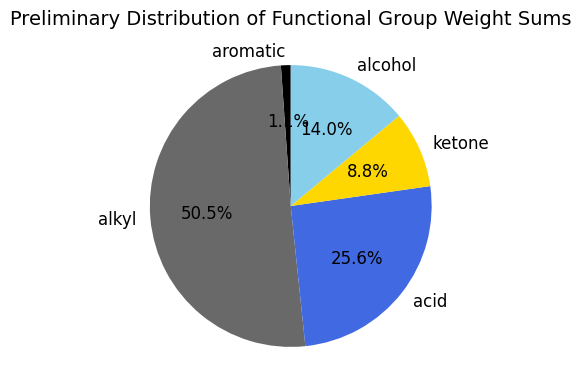

In [82]:
# This is the uncorrected data - it still needs to be corrected for O/C. However, this being plotted here because it is a good check-point. The final values after the O/C correction should be similar to this.
import matplotlib.pyplot as plt

# Extract labels and values from the summary_df
labels = summary_df.columns
values = summary_df.iloc[0].values

# Define custom colors for each functional group
custom_colors = {
    'aromatic': 'black',
    'alkyl': 'dimgray', # Dark grey
    'acid': 'royalblue',
    'ketone': 'gold',
    'alcohol': 'skyblue'
}

# Map labels to colors, ensuring the order matches the labels
colors = [custom_colors[label] for label in labels]

# Create the pie chart with a smaller figsize
fig, ax = plt.subplots(figsize=(4, 4)) # Decreased figsize from (8,8) to (4,4)
ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12}, colors=colors)
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title('Preliminary Distribution of Functional Group Weight Sums', fontsize=14, pad=20)

plt.show()

In [83]:
#This is the first type of correction. It is used when the estimated O/C is lower than the calculated O/C. It does not include ketones becuase this is correcting for less signal on oxygen due to dehydration
acid_percentage_contribution = summary_df.loc['percentage_contribution', 'acid']
alcohol_percentage_contribution = summary_df.loc['percentage_contribution', 'alcohol']
ketone_percentage_contribution = summary_df.loc['percentage_contribution', 'ketone']
alkyl_percentage_contribution = summary_df.loc['percentage_contribution', 'alkyl']
aromatic_percentage_contribution = summary_df.loc['percentage_contribution', 'aromatic']

weight_oxy_acid = (32/45) * acid_percentage_contribution * 100
weight_oxy_alcohol = (16/30) * alcohol_percentage_contribution * 100
weight_oxy_ketone = (16/28) * ketone_percentage_contribution * 100

weight_C_acid = (12/45) * acid_percentage_contribution * 100
weight_C_alcohol = (12/30) * alcohol_percentage_contribution * 100
weight_C_ketone = (12/28) * ketone_percentage_contribution * 100
weight_C_alkyl = (12/14) * alkyl_percentage_contribution * 100
weight_C_aromatic = (12/13) * aromatic_percentage_contribution * 100

O_num = (weight_oxy_acid + weight_oxy_alcohol + weight_oxy_ketone) / 16
C_num = (weight_C_acid + weight_C_alcohol + weight_C_ketone + weight_C_alkyl + weight_C_aromatic) / 12

Est_OC = O_num / C_num # This is the estimated O/C based on the fractions of functional groups without correction

print(f"Estimated O/C (Est_O/C): {Est_OC:.4f}")

#Now we calcuate the correction factor for the first type of correction (X1)

tot_C1 = weight_C_acid + weight_C_alcohol + weight_C_alkyl + weight_C_aromatic

denom_oxy = acid_percentage_contribution * 100 + alcohol_percentage_contribution * 100
denom_c_only = alkyl_percentage_contribution * 100 + aromatic_percentage_contribution * 100

# Handle potential division by zero if denominators are zero or very small
if denom_oxy == 0:
    val1 = 0
    val2 = 0
else:
    val1 = weight_C_acid / denom_oxy
    val2 = weight_C_alcohol / denom_oxy

if denom_c_only == 0:
    val3 = 0
    val4 = 0
else:
    val3 = weight_C_alkyl / denom_c_only
    val4 = weight_C_aromatic / denom_c_only

tot_C1a = val1 + val2 - val3 - val4

#print(f"\ntot_C1: {tot_C1:.4f}")
#print(f"tot_C1a: {tot_C1a:.4f}")

Tot_Oxy1 = weight_oxy_acid + weight_oxy_alcohol
Tot_Oxy1a = weight_oxy_acid / denom_oxy + weight_oxy_alcohol / denom_oxy

#print(f"Tot_Oxy1: {Tot_Oxy1:.4f}")
#print(f"Tot_Oxy1a: {Tot_Oxy1a:.4f}")

denominator_X1 = Tot_Oxy1a - (tot_C1a * OC * (16 / 12))

if denominator_X1 == 0:
    print("Cannot calculate X1: Denominator is zero.")
else:
    X1 = (((OC * (16 / 12) * tot_C1) - Tot_Oxy1) / denominator_X1)/100
    print(f"Calculated X1: {X1:.4f}")

Estimated O/C (Est_O/C): 0.3801
Calculated X1: -0.0637


In [84]:
#Now we calcuate the correction factor for the second type of correction (X2). This is correcting for a higher estimated O/C than calculated O/C.
#This comes from a lower signal for hydrocarbons in the sample, so the oxygen signal is being removed from all the groups (ketones are included here)

tot_C2 = weight_C_acid + weight_C_alcohol + weight_C_alkyl + weight_C_aromatic + weight_C_ketone

denom_oxy2 = acid_percentage_contribution * 100 + alcohol_percentage_contribution * 100 + ketone_percentage_contribution * 100
denom_c_only2 = alkyl_percentage_contribution * 100 + aromatic_percentage_contribution * 100

# Handle potential division by zero if denominators are zero or very small
if denom_oxy2 == 0:
    val5 = 0
    val6 = 0
    val7 = 0
else:
    val5 = weight_C_acid / denom_oxy2
    val6 = weight_C_alcohol / denom_oxy2
    val7 = weight_C_ketone / denom_oxy2

if denom_c_only == 0:
    val8 = 0
    val9 = 0
else:
    val8 = weight_C_alkyl / denom_c_only2
    val9 = weight_C_aromatic / denom_c_only2

tot_C2a = val5 + val6 + val7 - val8 - val9

#print(f"\ntot_C2: {tot_C2:.4f}")
#print(f"tot_C2a: {tot_C2a:.4f}")

Tot_Oxy2 = weight_oxy_acid + weight_oxy_alcohol + weight_oxy_ketone
Tot_Oxy2a = weight_oxy_acid / denom_oxy2 + weight_oxy_alcohol / denom_oxy2 + weight_oxy_ketone / denom_oxy2

#print(f"Tot_Oxy2: {Tot_Oxy2:.4f}")
#print(f"Tot_Oxy2a: {Tot_Oxy2a:.4f}")

denominator_X2 = Tot_Oxy2a - (tot_C2a * OC * (16 / 12))

if denominator_X2 == 0:
    print("Cannot calculate X1: Denominator is zero.")
else:
    X2 = (((OC * (16 / 12) * tot_C2) - Tot_Oxy2) / denominator_X2)/100
    print(f"Calculated X2: {X2:.4f}")

Calculated X2: -0.1101


In [85]:
#This is the decision block. If the estimated O/C (using the functioanl groups) is higher than that calculated using the IA method, it will use X2. If the estimated O/C is lower, it will use X1.
if Est_OC > OC:
    print("Est_OC is greater than the calculated OC, so X2 would be used.")
    selected_correction_factor = 'X2'
else:
    print("Est_OC is less than or equal to the calculated OC, so X1 would be used.")
    selected_correction_factor = 'X1'

print(f"Selected Correction Factor: {selected_correction_factor}")

#Now we do the corrections
# Get the numerical value of the selected correction factor
if selected_correction_factor == 'X1':
    correction_value = X1
elif selected_correction_factor == 'X2':
    correction_value = X2
else:
    correction_value = 0 # Default or error handling

final_aromatic_percent = aromatic_percentage_contribution - \
                   (correction_value * \
                    (aromatic_percentage_contribution / (aromatic_percentage_contribution + alkyl_percentage_contribution)))

final_alkyl_percent = alkyl_percentage_contribution - \
                 (correction_value * \
                  (alkyl_percentage_contribution / (alkyl_percentage_contribution + aromatic_percentage_contribution)))


# Calculate corrections for acid, ketone, and alcohol based on selected_correction_factor
if selected_correction_factor == 'X1':
    denom_acid_alcohol = acid_percentage_contribution + alcohol_percentage_contribution
    if denom_acid_alcohol != 0:
        final_acid_percent = acid_percentage_contribution + (correction_value * (acid_percentage_contribution / denom_acid_alcohol))
        final_alcohol_percent = alcohol_percentage_contribution + (correction_value * (alcohol_percentage_contribution / denom_acid_alcohol))
    else:
        final_acid_percent = acid_percentage_contribution
        final_alcohol_percent = alcohol_percentage_contribution
    final_ketone_percent = ketone_percentage_contribution # Ketone unchanged for X1

elif selected_correction_factor == 'X2':
    denom_acid_ketone_alcohol = acid_percentage_contribution + ketone_percentage_contribution + alcohol_percentage_contribution
    if denom_acid_ketone_alcohol != 0:
        final_acid_percent = acid_percentage_contribution + (correction_value * (acid_percentage_contribution / denom_acid_ketone_alcohol))
        final_alcohol_percent = alcohol_percentage_contribution + (correction_value * (alcohol_percentage_contribution / denom_acid_ketone_alcohol))
        final_ketone_percent = ketone_percentage_contribution + (correction_value * (ketone_percentage_contribution / denom_acid_ketone_alcohol))
    else:
        final_acid_percent = acid_percentage_contribution
        final_alcohol_percent = alcohol_percentage_contribution
        final_ketone_percent = ketone_percentage_contribution
else:
    final_acid_percent = acid_percentage_contribution
    final_alcohol_percent = alcohol_percentage_contribution
    final_ketone_percent = ketone_percentage_contribution

Est_OC is greater than the calculated OC, so X2 would be used.
Selected Correction Factor: X2


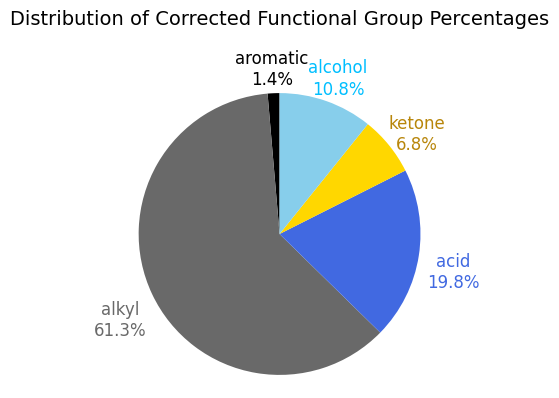


Raw Final Percentages (including negative values):
Final Aromatic Percent: 1.4
Final Alkyl Percent: 61.3
Final Acid Percent: 19.8
Final Ketone Percent: 6.8
Final Alcohol Percent: 10.8
Estimated O/C: 0.380
IA calculated O/C: 0.268
IA calculated H/C: 1.730
IA calculated N/C: 0.010


In [86]:
import matplotlib.pyplot as plt
import os
import numpy as np

# Collect the newly calculated percentage values
labels = ['aromatic', 'alkyl', 'acid', 'ketone', 'alcohol']

# Combine the final calculated percentages into a list
original_values = [
    final_aromatic_percent,
    final_alkyl_percent,
    final_acid_percent,
    final_ketone_percent,
    final_alcohol_percent
]

# Ensure all values are non-negative for plotting and re-normalize
# Convert to numpy array to use np.maximum efficiently
values_np = np.array(original_values)
positive_values_np = np.maximum(0, values_np)

# Check if the sum of positive values is zero to avoid division by zero
if positive_values_np.sum() == 0:
    print("All final percentage contributions are zero or negative after correction. Cannot create a meaningful pie chart.")
else:
    # Normalize the positive values so they sum to 1 (for 100% in pie chart)
    normalized_values = positive_values_np / positive_values_np.sum()

    # Define custom colors for each functional group (for wedges)
    custom_colors = {
        'aromatic': 'black',
        'alkyl': 'dimgray',
        'acid': 'royalblue',
        'ketone': 'gold',
        'alcohol': 'skyblue'
    }

    # Define custom colors for text, with darker shades for readability where needed
    text_custom_colors = {
        'aromatic': 'black',
        'alkyl': 'dimgray',
        'acid': 'royalblue',
        'ketone': 'darkgoldenrod', # Darker yellow for text
        'alcohol': 'deepskyblue'   # Darker skyblue for text
    }

    # Map labels to wedge colors
    color_list = [custom_colors[label] for label in labels]
    # Map labels to text colors
    text_color_list = [text_custom_colors[label] for label in labels]

    # Create the pie chart with a smaller figsize
    fig, ax = plt.subplots(figsize=(4, 4)) # Decreased figsize for a more compact chart

    # Draw the pie chart, obtaining the text objects for labels and percentages.
    # `labeldistance` and `pctdistance` initially set them to the same radial distance outside the circle.
    wedges, texts, autotexts = ax.pie(
        normalized_values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=color_list,
        textprops={'fontsize': 12}, # Apply fontsize to the main labels ('texts')
        labeldistance=1.25, # Position labels outside the circle
        pctdistance=1.25    # Initially position percentages outside at the same radial distance
    )

    # Iterate over the label and percentage text objects to adjust their positions
    for i, (text_label, text_pct) in enumerate(zip(texts, autotexts)):
        # Get the original position of the main label
        x, y = text_label.get_position()

        # Adjust the vertical position of the percentage text to be directly below the label
        # The offset might need fine-tuning depending on font sizes and desired spacing.
        offset = 0.15 # This value controls the vertical separation between label and percentage
        text_pct.set_position((x, y - offset))

        # Ensure both are horizontally centered
        text_label.set_horizontalalignment('center')
        text_pct.set_horizontalalignment('center')

        # Set color and fontsize for percentages, as `textprops` only applied to labels.
        text_pct.set_color(text_color_list[i])
        text_label.set_color(text_color_list[i])
        text_pct.set_fontsize(12)

    ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    ax.set_title(f'Distribution of Corrected Functional Group Percentages', fontsize=14, pad=40)

    plt.show()

# Print the raw final percentages (including negative values) for debugging/information
print("\nRaw Final Percentages (including negative values):")
print(f"Final Aromatic Percent: {final_aromatic_percent*100:.1f}")
print(f"Final Alkyl Percent: {final_alkyl_percent*100:.1f}")
print(f"Final Acid Percent: {final_acid_percent*100:.1f}")
print(f"Final Ketone Percent: {final_ketone_percent*100:.1f}")
print(f"Final Alcohol Percent: {final_alcohol_percent*100:.1f}")
print(f"Estimated O/C: {Est_OC:.3f}")  # estimate from functional groups before correction
print(f"IA calculated O/C: {OC:.3f}")
print(F"IA calculated H/C: {HC:.3f}")
print(f"IA calculated N/C: {NC:.3f}")